## Job Market Analysis

This analysis explores job market trends across roles, platforms, job types, and remote work patterns.  
The goal is to identify where opportunities exist and how work preferences impact demand and salary.

In [1]:
import pandas as pd

# Loading the cleaned job dataset 
# (.pkl format is imported since it retains python objects like list and idctionaries unlike .csv wich converts them to string)
df = pd.read_pickle("../data/processed/cleaned_jobs.pkl")

df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_id
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",[Work Nearby],Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,[],{},J-e02c886264ce
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",[BeBee México],Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[nosql, power bi, python, r, sql, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr...",J-64833455be38
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",[LinkedIn],Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[airflow, azure, c#, dax, docker, jenkins, kub...","{'analyst_tools': ['dax'], 'cloud': ['azure'],...",J-c8afb754b830
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",[Diversity.com],Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[aws, c++, java, keras, matlab, python, pytorc...","{'cloud': ['aws'], 'libraries': ['keras', 'pyt...",J-6b595ba75824
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",[Clearance Jobs],Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[ansible, aws, bash, git, gitlab, jenkins, ora...","{'cloud': ['aws', 'oracle'], 'other': ['ansibl...",J-88bb30c3cf7d


## Job Schedule Type Distribution

- A bar chart is used to display the proportion of the most common schedule types.
- Values are normalized to represent percentages of total job postings.
- Percentage labels are added to each bar for clear interpretation.

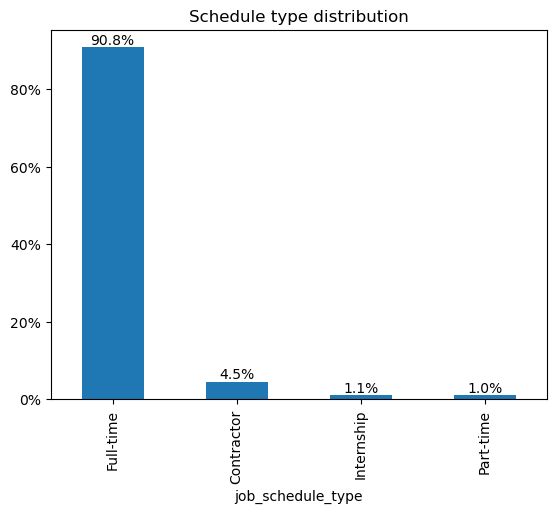

In [2]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Create bar chart showing distribution of top 4 job schedule types (as proportions)
ax = df['job_schedule_type'].value_counts(normalize=True).head(4).plot(
    kind='bar',
    title='Schedule type distribution'
)

# Remove gridlines for cleaner appearance
plt.grid(False)

# Add percentage labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height*100:.1f}%',                     # Convert proportion to percentage
        (p.get_x() + p.get_width()/2, height),   # Position label at center-top of bar
        ha='center',
        va='bottom',
        fontsize=10
    )

# Format y-axis to display percentage values
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x*100:.0f}%')
)

# Display the plot
plt.show()

In [3]:
# Identify the top 4 most common job schedule types based on frequency
top_schedule_types = df['job_schedule_type'].value_counts().head(4)

top_schedule_types

job_schedule_type
Full-time     700926
Contractor     34761
Internship      8737
Part-time       7869
Name: count, dtype: int64

In [4]:
# Create a cross-tabulation of roles vs job schedule types,
# normalized by row to show proportion distribution within each role
role_jobtype = pd.crosstab(
    df['job_title_short'],
    df['job_schedule_type'],
    normalize='index'
)

role_jobtype

job_schedule_type,Contractor,Contractor and Full-time,Contractor and Internship,Contractor and Part-time,Contractor and Per diem,Contractor and Temp work,"Contractor, Temp work, and Internship",Full-time,Full-time and Contractor,Full-time and Internship,...,"Part-time, Contractor, and Temp work","Part-time, Internship, and Volunteer","Part-time, Temp work, and Internship",Pekerjaan tetap,Per diem,Temp work,Temp work and Full-time,Temp work and Internship,"Temp work, Full-time, and Part-time",Volunteer
job_title_short,,,,,,,,,,,,,,,,,,,,,
Business Analyst,0.035424,0.000000,0.000126,0.000000,0.000021,0.002094,0.000000,0.922473,0.003015,0.002282,...,0.000021,0.000000,0.000021,0.000105,0.000000,0.003161,0.000000,0.000251,0.000000,0.000063
Cloud Engineer,0.026785,0.000000,0.000082,0.000000,0.000000,0.001479,0.000000,0.947170,0.003204,0.000822,...,0.000000,0.000000,0.000000,0.000082,0.000000,0.003533,0.000000,0.000000,0.000000,0.000000
Data Analyst,0.052268,0.000005,0.000042,0.000000,0.000010,0.002870,0.000005,0.882493,0.003351,0.004324,...,0.000031,0.000000,0.000026,0.000026,0.000078,0.004036,0.000000,0.000465,0.000000,0.000131
Data Engineer,0.062594,0.000000,0.000033,0.000016,0.000000,0.004041,0.000000,0.899943,0.003425,0.001980,...,0.000033,0.000000,0.000011,0.000142,0.000005,0.002498,0.000000,0.000125,0.000005,0.000027
Data Scientist,0.036161,0.000000,0.000094,0.000000,0.000006,0.003435,0.000006,0.900759,0.002635,0.005477,...,0.000035,0.000006,0.000018,0.000018,0.000018,0.002577,0.000000,0.000482,0.000000,0.000088
Machine Learning Engineer,0.029467,0.000000,0.000072,0.000000,0.000000,0.002305,0.000072,0.932205,0.002810,0.002666,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.001945,0.000000,0.000000,0.000000,0.000072
Senior Data Analyst,0.033675,0.000000,0.000000,0.000000,0.000000,0.001743,0.000000,0.941609,0.002475,0.000035,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.001987,0.000000,0.000000,0.000000,0.000035
Senior Data Engineer,0.045238,0.000000,0.000000,0.000000,0.000000,0.002792,0.000000,0.931451,0.002769,0.000000,...,0.000000,0.000000,0.000000,0.000159,0.000000,0.001248,0.000000,0.000023,0.000000,0.000000
Senior Data Scientist,0.020447,0.000000,0.000000,0.000000,0.000000,0.001172,0.000000,0.960005,0.001609,0.000191,...,0.000000,0.000000,0.000000,0.000027,0.000000,0.001200,0.000000,0.000000,0.000000,0.000000


In [5]:
# Identify the top 3 most frequent job roles based on number of postings
top_roles = df['job_title_short'].value_counts().head(3).index

In [6]:
# Filter the cross-tab to include only the top roles
role_jobtype = role_jobtype.loc[top_roles]

# Keep only the most common schedule types (top 4)
role_jobtype = role_jobtype[top_schedule_types.index]

role_jobtype

job_schedule_type,Full-time,Contractor,Internship,Part-time
job_title_short,,,,
Data Analyst,0.882493,0.052268,0.017191,0.016710
Data Engineer,0.899943,0.062594,0.006785,0.006616
Data Scientist,0.900759,0.036161,0.018954,0.012760


In [7]:
# Remove 'Full-time' column to focus on alternative or less dominant schedule types
role_jobtype_filtered = role_jobtype.drop(columns=['Full-time'])

## Job Type Distribution by Role (Excluding Full-time)

This visualization analyzes how different job schedule types (excluding full-time roles) are distributed across key data roles, highlighting variations in work arrangements.

- A horizontal stacked bar chart is used to compare the proportion of job types across roles.
- Full-time roles are excluded to focus on alternative work arrangements such as contract, part-time, or temporary roles.
- Each bar represents a role, segmented by job type proportions.
- Percentage labels are added within segments for clarity, excluding very small values to reduce clutter.

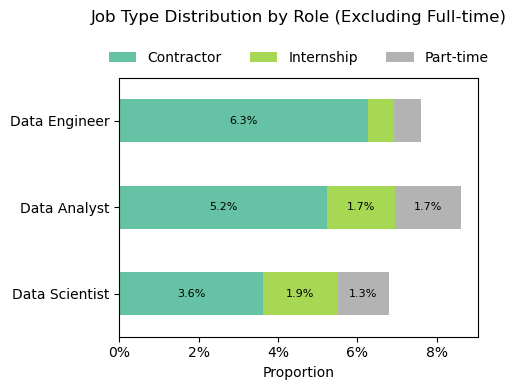

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

role_jobtype_filtered = role_jobtype_filtered.sort_values(by='Contractor', ascending=False)
ax = role_jobtype_filtered.plot(
    kind='barh',              # 👈 horizontal
    stacked=True,
    figsize=(5,4),
    colormap='Set2'
)

for i, row in enumerate(role_jobtype_filtered.values):
    cumulative = 0
    for j, val in enumerate(row):
        if val > 0.01:  # avoid tiny clutter labels
            ax.text(
                cumulative + val/2,
                i,
                f"{val*100:.1f}%",
                ha='center',
                va='center',
                fontsize=8,
                color='black'
            )
        cumulative += val

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{int(x*100)}%')
)
ax.invert_yaxis()

plt.title('Job Type Distribution by Role (Excluding Full-time)', pad=40)
plt.xlabel('Proportion')
plt.ylabel('')

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{int(x*100)}%')
)

plt.legend(
    title='',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),  # 👈 adjust height if needed
    ncol=3,                      # 👈 horizontal layout
    frameon=False
)

plt.tight_layout()
plt.show()

In [9]:
# Expand the 'job_via' column so each source gets its own row (useful for multi-source listings)
df_jobvia = df.explode('job_via')

In [10]:
# Identify the top 5 job platforms based on frequency of postings
top5_platforms = df_jobvia['job_via'].value_counts().head(5)

top5_platforms.index

Index(['LinkedIn', 'BeBee', 'Trabajo.org', 'Indeed', 'Recruit.net'], dtype='str', name='job_via')

In [11]:
# Calculate posting counts for each role-platform combination
# and sort within each role by frequency (highest to lowest)
top_platforms = (
    df_jobvia.groupby(['job_title_short', 'job_via'])
    .size()
    .reset_index(name='count')
    .sort_values(['job_title_short', 'count'], ascending=[True, False])
)

top_platforms

,job_title_short,job_via,count
1052,Business Analyst,LinkedIn,8619
125,Business Analyst,BeBee,7526
1613,Business Analyst,Trabajo.org,5307
703,Business Analyst,Indeed,1767
1796,Business Analyst,ZipRecruiter,1352
...,...,...,...
19957,Software Engineer,キャリアクロス,1
19960,Software Engineer,台湾職缺 - Jooble,1
19964,Software Engineer,日経転職版 - 日本経済新聞,1
19965,Software Engineer,転職会議,1


In [12]:
# For each role-platform combination, retain the aggregated count and sort by frequency (highest first)
top_platforms_per_role = top_platforms.groupby(
    ['job_title_short', 'job_via']
).first().sort_values(['count'], ascending=False)

top_platforms_per_role

count
job_title_short       job_via                            
Data Engineer         LinkedIn                      58784
Data Analyst          LinkedIn                      41750
Data Scientist        LinkedIn                      37445
                      BeBee                         26590
Data Analyst          BeBee                         25756
...                                                   ...
                      Jobagent.ch                       1
Software Engineer     Фреш-Джоб                         1
                      Работа В Узбекистане              1
                      Работа В Таразе - HeadHunter      1
Senior Data Scientist The Home Depot - Talentify        1

[19972 rows x 1 columns]

In [13]:
# Reshape the data to create a pivot table showing platform counts per role
top5_platforms_per_role = top_platforms_per_role.pivot_table(
    values='count',
    index='job_title_short',   # Rows represent job roles
    columns='job_via'          # Columns represent job platforms
)

top5_platforms_per_role

job_via,- Career Associated,- The Intersect Group,1/ST Technology | Careers Center - ICIMS,10 Chambers,100000jobs.ch,100Hires.com,104人力銀行,1111人力銀行,123work,1840 & Company,...,인디드,자소설닷컴,잡플래닛,채용 - Jooble,채용공고 검색 엔진 | SimplyHired,캐치,프로그래머스 커리어,피플앤잡,하이브레인넷,🇩‌🇮‌🇸‌🇶‌🇦‌🇻‌🇦‌🇩‌ – Discover English Speaking Jobs In Germany
job_title_short,,,,,,,,,,,,,,,,,,,,,
Business Analyst,4.0,NaN,NaN,NaN,NaN,1.0,24.0,4.0,NaN,NaN,...,7.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
Cloud Engineer,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,...,6.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
Data Analyst,12.0,NaN,NaN,NaN,NaN,NaN,42.0,25.0,3.0,2.0,...,57.0,NaN,NaN,1.0,NaN,6.0,1.0,18.0,1.0,NaN
Data Engineer,7.0,1.0,1.0,NaN,1.0,NaN,52.0,32.0,NaN,NaN,...,80.0,NaN,1.0,3.0,2.0,8.0,7.0,9.0,NaN,NaN
Data Scientist,7.0,NaN,NaN,NaN,NaN,NaN,39.0,15.0,NaN,3.0,...,75.0,1.0,NaN,2.0,5.0,17.0,5.0,20.0,1.0,2.0
Machine Learning Engineer,NaN,NaN,NaN,NaN,NaN,NaN,7.0,2.0,NaN,NaN,...,9.0,NaN,NaN,2.0,1.0,NaN,3.0,NaN,NaN,NaN
Senior Data Analyst,4.0,NaN,NaN,NaN,1.0,NaN,3.0,2.0,NaN,NaN,...,4.0,NaN,NaN,1.0,NaN,1.0,1.0,1.0,NaN,NaN
Senior Data Engineer,NaN,NaN,NaN,NaN,NaN,NaN,7.0,2.0,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
Senior Data Scientist,NaN,NaN,NaN,1.0,NaN,NaN,6.0,1.0,NaN,NaN,...,4.0,NaN,NaN,1.0,NaN,NaN,NaN,4.0,NaN,NaN


In [14]:
# Filter the pivot table to include only the top 5 most frequent job platforms
top5_platforms_per_role = top5_platforms_per_role[top5_platforms.index]

top5_platforms_per_role

job_via,LinkedIn,BeBee,Trabajo.org,Indeed,Recruit.net
job_title_short,,,,,
Business Analyst,8619.0,7526.0,5307.0,1767.0,1327.0
Cloud Engineer,1247.0,2758.0,1958.0,132.0,444.0
Data Analyst,41750.0,25756.0,15477.0,12929.0,5949.0
Data Engineer,58784.0,18005.0,9054.0,11259.0,5118.0
Data Scientist,37445.0,26590.0,13617.0,10079.0,4921.0
Machine Learning Engineer,3003.0,1990.0,1210.0,518.0,522.0
Senior Data Analyst,6801.0,3512.0,2566.0,1443.0,1007.0
Senior Data Engineer,14907.0,3557.0,2084.0,2235.0,1239.0
Senior Data Scientist,8881.0,5217.0,3110.0,1732.0,1186.0


In [15]:
# Filter the pivot table to include only the selected top roles
top5_platforms_per_top_roles = top5_platforms_per_role.loc[top_roles]

top5_platforms_per_top_roles

job_via,LinkedIn,BeBee,Trabajo.org,Indeed,Recruit.net
job_title_short,,,,,
Data Analyst,41750.0,25756.0,15477.0,12929.0,5949.0
Data Engineer,58784.0,18005.0,9054.0,11259.0,5118.0
Data Scientist,37445.0,26590.0,13617.0,10079.0,4921.0


In [16]:
# Normalize platform counts to proportions within each role (row-wise)
pivot = top5_platforms_per_top_roles.div(
    top5_platforms_per_top_roles.sum(axis=1), axis=0
)

pivot

job_via,LinkedIn,BeBee,Trabajo.org,Indeed,Recruit.net
job_title_short,,,,,
Data Analyst,0.409872,0.252854,0.151942,0.126928,0.058403
Data Engineer,0.575073,0.176140,0.088574,0.110145,0.050068
Data Scientist,0.404147,0.286988,0.146969,0.108783,0.053113


## Job Platform Distribution by Role

This analysis examines how job postings for different roles are distributed across major hiring platforms, helping identify which platforms dominate for each role.

- A horizontal bar chart is used to compare platform share across roles.
- Each role is broken down by the percentage of job postings from the top platforms.
- Roles are ordered based on their reliance on LinkedIn, providing a consistent reference point.
- The chart focuses on the top 5 platforms to highlight the most relevant sources.

In [17]:
# Convert the pivot table to long format for easier plotting and analysis
pivot_long = pivot.reset_index().melt(
    id_vars='job_title_short',   # Keep role as identifier
    var_name='job_via',          # Column representing job platforms
    value_name='percentage'      # Proportion of postings per platform
)

pivot_long

,job_title_short,job_via,percentage
0,Data Analyst,LinkedIn,0.409872
1,Data Engineer,LinkedIn,0.575073
2,Data Scientist,LinkedIn,0.404147
3,Data Analyst,BeBee,0.252854
4,Data Engineer,BeBee,0.176140
5,Data Scientist,BeBee,0.286988
6,Data Analyst,Trabajo.org,0.151942
7,Data Engineer,Trabajo.org,0.088574
8,Data Scientist,Trabajo.org,0.146969
9,Data Analyst,Indeed,0.126928


In [18]:
# Determine the order of roles based on total platform share (descending)
order = pivot_long.groupby('job_title_short')['percentage'] \
    .sum().sort_values(ascending=False).index

### Plot Top platforms graph

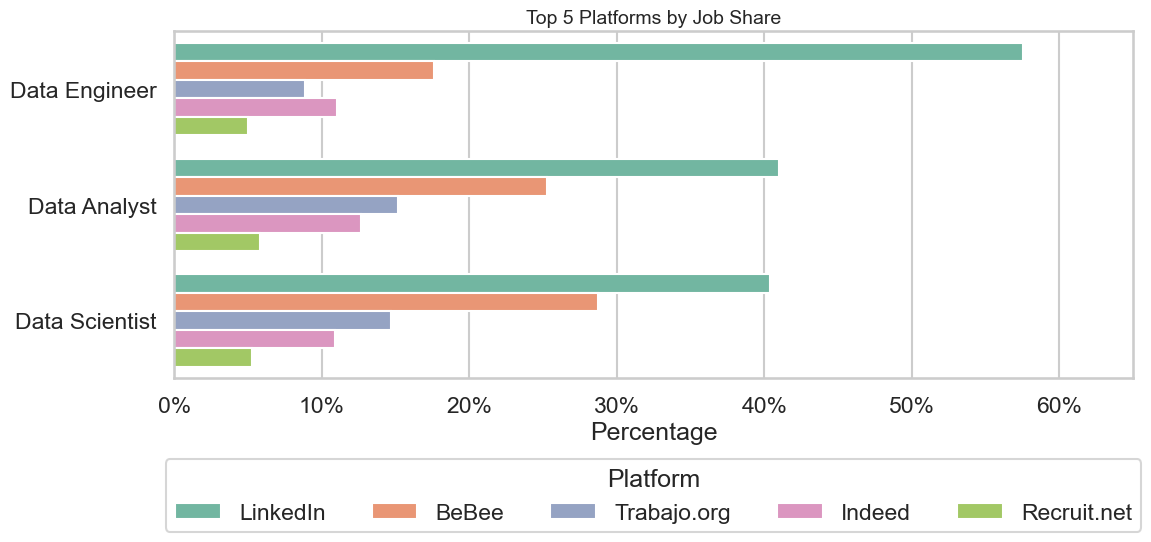

In [19]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Set visual styling for consistency and readability
sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette("Set2")

# Create figure
plt.figure(figsize=(12, 6))

# Order roles based on percentage of postings from LinkedIn (descending)
order = (
    pivot_long[pivot_long['job_via'] == 'LinkedIn']
    .sort_values('percentage', ascending=False)['job_title_short']
)

# Define order of platforms in legend (optional for consistency)
hue_order = ['LinkedIn', 'BeBee', 'Trabajo.org', 'Indeed', 'Recruit.net']

# Create horizontal grouped bar chart
sns.barplot(
    data=pivot_long,
    y='job_title_short',
    x='percentage',
    hue='job_via',
    order=order
)

# Set title and labels
plt.title('Top 5 Platforms by Job Share', fontsize=14)
plt.xlabel('Percentage')
plt.ylabel('')

# Set x-axis limits and format as percentage
plt.xlim(0, 0.65)
plt.gca().xaxis.set_major_formatter(lambda x, _: f'{x*100:.0f}%')

# Position legend below the chart
plt.legend(
    title='Platform',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=5
)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

## Remote vs Non-Remote Salary Comparison

This analysis compares median salaries between remote and on-site roles to evaluate the impact of work arrangement on compensation.

- A bar chart is used to compare salaries for remote and non-remote roles.
- Salaries are formatted in thousands (K) for better readability.
- Clear labeling distinguishes between on-site and remote work categories.

In [20]:
# Calculate the median salary based on remote work availability (True/False)
remote_salary = df.groupby('job_work_from_home')['salary_year_avg'].median()

remote_salary

job_work_from_home
False    115000.0000
True     128914.8125
Name: salary_year_avg, dtype: float64

### Plot remote vs non-remote salary comparison graph

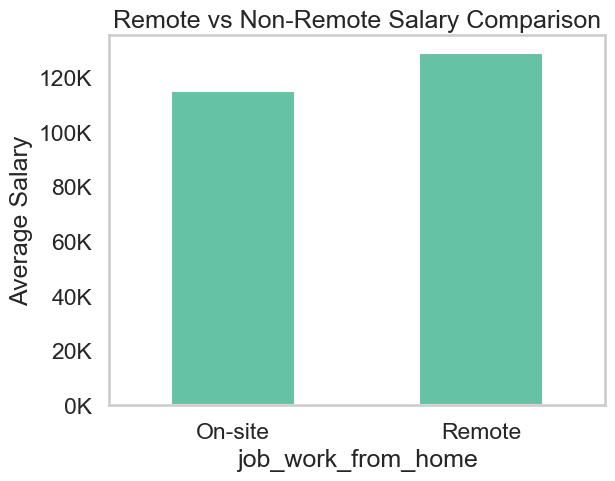

In [21]:
# Import formatter for displaying salary values in thousands
from matplotlib.ticker import FuncFormatter

# Plot bar chart comparing remote vs non-remote salaries
remote_salary.plot(kind='bar')

# Set chart title and y-axis label
plt.title('Remote vs Non-Remote Salary Comparison')
plt.ylabel('Average Salary')

# Format y-axis values in thousands (K)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{int(x/1000)}K')
)

# Customize x-axis labels for clarity
plt.xticks([0, 1], ['On-site', 'Remote'], rotation=0)

# Remove gridlines for cleaner look
plt.grid(False)

# Display the plot
plt.show()

In [22]:
# Filter the dataset to include only the selected top roles
df_roles = df[df['job_title_short'].isin(top_roles)]

# Extract month from job posting date and convert it to a monthly period format
df_roles['month'] = pd.to_datetime(df_roles['job_posted_date']).dt.to_period('M')

df_roles

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_id,month
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",[BeBee México],Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[nosql, power bi, python, r, sql, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr...",J-64833455be38,2023-01
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",[LinkedIn],Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[airflow, azure, c#, dax, docker, jenkins, kub...","{'analyst_tools': ['dax'], 'cloud': ['azure'],...",J-c8afb754b830,2023-10
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",[Diversity.com],Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[aws, c++, java, keras, matlab, python, pytorc...","{'cloud': ['aws'], 'libraries': ['keras', 'pyt...",J-6b595ba75824,2023-07
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",[Clearance Jobs],Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[ansible, aws, bash, git, gitlab, jenkins, ora...","{'cloud': ['aws', 'oracle'], 'other': ['ansibl...",J-88bb30c3cf7d,2023-08
5,Data Engineer,GCP Data Engineer,Anywhere,[ZipRecruiter],Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"[gcp, python, sql]","{'cloud': ['gcp'], 'programming': ['python', '...",J-39b48817780e,2023-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785730,Data Engineer,"Data Center Engineering Operations Engineer , ...","Bangkok, Thailand",[melalui LinkedIn],Pekerjaan tetap,False,Thailand,2023-03-12 06:37:47,False,False,Thailand,NaN,NaN,NaN,Amazon Web Services (AWS),"[excel, outlook, word]","{'analyst_tools': ['excel', 'outlook', 'word']}",J-59d13e2c5e95,2023-03
785731,Data Engineer,Data Engineer,"Overland Park, Kansas, Amerika Serikat",[melalui LinkedIn],Pekerjaan tetap,False,Sudan,2023-03-12 06:32:17,False,False,Sudan,NaN,NaN,NaN,Shamrock Trading Corporation,"[aws, docker, elasticsearch, excel, git, kafka...","{'analyst_tools': ['excel'], 'cloud': ['aws', ...",J-01b0f86f464d,2023-03
785732,Data Engineer,Data Engineer (f/m/d),"Heidelberg, Jerman",[melalui Top County Careers],Pekerjaan tetap,False,Germany,2023-03-13 06:18:59,False,False,Germany,NaN,NaN,NaN,Heidelberg Materials,"[azure, c#, databricks, gitlab, java, postgres...","{'cloud': ['azure', 'databricks'], 'databases'...",J-898e6ed0a420,2023-03
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",[melalui BeBee Deutschland],Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"[excel, sas, sql]","{'analyst_tools': ['excel', 'sas'], 'programmi...",J-8fc5a53a787e,2023-03


In [23]:
# Aggregate job postings by month and role, then reshape to have roles as columns
jobs_role_trend = (
    df_roles
    .groupby(['month', 'job_title_short'])
    .size()
    .unstack()
).copy()

jobs_role_trend

job_title_short,Data Analyst,Data Engineer,Data Scientist
month,,,
2023-01,23568,21391,20736
2023-02,16541,15882,13942
2023-03,16231,16081,13561
2023-04,15496,14877,13501
2023-05,13413,13635,11735
2023-06,15994,15487,13606
2023-07,16083,14493,14161
2023-08,18587,15592,16959
2023-09,14948,14890,13567


In [24]:
# Calculate the proportion of remote jobs by month and role, then reshape to wide format
remote_role_trend = (
    df_roles
    .groupby(['month', 'job_title_short'])['job_work_from_home']
    .mean()   # Mean gives proportion of remote roles (True = 1, False = 0)
    .unstack()
)

remote_role_trend

job_title_short,Data Analyst,Data Engineer,Data Scientist
month,,,
2023-01,0.067295,0.093638,0.085696
2023-02,0.061786,0.104458,0.082054
2023-03,0.064629,0.109632,0.082737
2023-04,0.059499,0.094239,0.073476
2023-05,0.066354,0.110231,0.085471
2023-06,0.066713,0.109640,0.086873
2023-07,0.065286,0.114193,0.085940
2023-08,0.045838,0.087288,0.055605
2023-09,0.077602,0.134587,0.092430


## Job Market Trends: Volume vs Remote Share

This analysis tracks how job demand and remote work adoption evolve over time across key data roles.

- The first chart shows the number of job postings over time, highlighting demand trends for each role.
- The second chart shows the proportion of remote roles over time, indicating how work flexibility is changing.
- Both charts are aligned on the same timeline for direct comparison.

### Plot Job Market Trends Graph

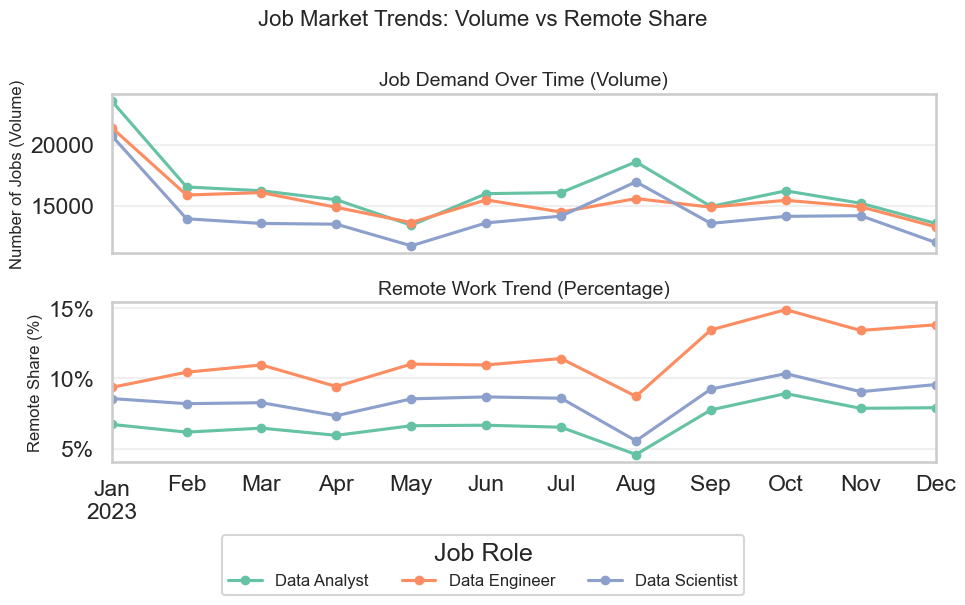

In [25]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Set visual styling
sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette("Set2")

# Create figure with two vertically stacked subplots (shared x-axis)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Set overall title
fig.suptitle('Job Market Trends: Volume vs Remote Share', fontsize=16)

# ---------------------------
# 1. Job postings (Volume)
# ---------------------------
# Plot number of job postings over time for each role
jobs_role_trend.plot(ax=axes[0], marker='o', markersize=6)

# Set title and labels
axes[0].set_title('Job Demand Over Time (Volume)', fontsize=14)
axes[0].set_ylabel('Number of Jobs (Volume)', fontsize=12)

# Temporary legend (will be consolidated later)
axes[0].legend(title='Role', bbox_to_anchor=(1.05, 1))


# ---------------------------
# 2. Remote share (%)
# ---------------------------
# Plot proportion of remote jobs over time for each role
remote_role_trend.plot(ax=axes[1], marker='o', markersize=6)

# Set title and labels
axes[1].set_title('Remote Work Trend (Percentage)', fontsize=14)
axes[1].set_ylabel('Remote Share (%)', fontsize=12)
axes[1].set_xlabel('')

# Format y-axis as percentage
axes[1].yaxis.set_major_formatter(lambda x, _: f'{x*100:.0f}%')

# Temporary legend (will be consolidated later)
axes[1].legend(title='Role', bbox_to_anchor=(1.05, 1))

# Remove individual legends to replace with a shared legend
axes[0].legend().remove()
axes[1].legend().remove()

# Add light gridlines for readability
axes[0].grid(alpha=0.3)
axes[1].grid(alpha=0.3)

# Extract legend handles and labels from first plot
handles, labels = axes[0].get_legend_handles_labels()

# Create a shared legend below both charts
fig.legend(
    handles,
    labels,
    title='Job Role',
    fontsize=12,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.01),
    ncol=3
)

# Adjust layout to accommodate legend
plt.tight_layout(rect=[0, 0.08, 1, 1])

# Display the plots
plt.show()

In [26]:
# Count the number of job postings for each platform
platform_counts = df_jobvia['job_via'].value_counts()

platform_counts

job_via
LinkedIn                186534
BeBee                   103406
Trabajo.org              61490
Indeed                   42712
Recruit.net              23636
                         ...  
melalui KHON2 Jobs           1
melalui Startup Jobs         1
melalui Melga                1
melalui Ricebowl             1
melalui Trigyn               1
Name: count, Length: 7903, dtype: int64

In [27]:
# Filter platforms with more than 200 job postings to keep only significant sources
valid_platforms = platform_counts[platform_counts > 200].index

valid_platforms

Index(['LinkedIn', 'BeBee', 'Trabajo.org', 'Indeed', 'Recruit.net',
       'ZipRecruiter', 'Jobs Trabajo.org', 'Snagajob',
       'Trabajo.org - Vacantes De Empleo, Trabajo', 'BeBee India',
       ...
       'Learn4Good.com', 'Boston Consulting Group', 'Snowflake Careers',
       'JobiJoba.de', 'Indeed 台灣', 'Monster.fr', 'UNjobnet',
       'LinkedIn Armenia', 'Star Job Search', 'Indeed Argentina'],
      dtype='str', name='job_via', length=203)

In [28]:
# Calculate the proportion of remote jobs for each valid platform and sort descending
remote_platform = (
    df_jobvia[df_jobvia['job_via'].isin(valid_platforms)]
    .groupby('job_via')['job_work_from_home']
    .mean()   # Mean gives remote share (True = 1, False = 0)
    .sort_values(ascending=False)
)

remote_platform.head(10)

job_via
Upwork              1.000000
VentureLoop         1.000000
Jobgether           1.000000
JobTeaser           0.958929
Get.It              0.813910
LinkedIn Armenia    0.582090
IrishJobs.ie        0.463074
Totaljobs           0.438580
AngelList           0.397500
HelloWork           0.394052
Name: job_work_from_home, dtype: float64

In [29]:
# Convert remote share from proportion to percentage
remote_platform_pct = remote_platform * 100

remote_platform_pct.head(10)

job_via
Upwork              100.000000
VentureLoop         100.000000
Jobgether           100.000000
JobTeaser            95.892857
Get.It               81.390977
LinkedIn Armenia     58.208955
IrishJobs.ie         46.307385
Totaljobs            43.857965
AngelList            39.750000
HelloWork            39.405204
Name: job_work_from_home, dtype: float64

## Remote vs On-Site Distribution by Platform

This visualization compares the proportion of remote and on-site job postings across major platforms to identify which platforms are more remote-friendly.

- A dumbbell chart is used to show the gap between remote and on-site job shares for each platform.
- Each line connects the on-site percentage (left) to the remote percentage (right).
- Colored points represent:
  - Red: On-site share  
  - Green: Remote share  
- Labels are dynamically positioned to avoid overlap and improve readability.

In [30]:
# Select top 10 platforms and convert Series to DataFrame
platform_df = remote_platform_pct.head(10).reset_index()

# Rename columns for clarity
platform_df.columns = ['Platform', 'Remote_Percentage']

# Sort platforms by remote percentage (ascending for plotting)
platform_df = platform_df.sort_values('Remote_Percentage')

# Calculate non-remote percentage for comparison
platform_df['Non_Remote'] = 100 - platform_df['Remote_Percentage']

platform_df

,Platform,Remote_Percentage,Non_Remote
9,HelloWork,39.405204,60.594796
8,AngelList,39.750000,60.250000
7,Totaljobs,43.857965,56.142035
6,IrishJobs.ie,46.307385,53.692615
5,LinkedIn Armenia,58.208955,41.791045
4,Get.It,81.390977,18.609023
3,JobTeaser,95.892857,4.107143
2,Jobgether,100.000000,0.000000
1,VentureLoop,100.000000,0.000000
0,Upwork,100.000000,0.000000


### Plot remote vs on-site job distribution gap graph

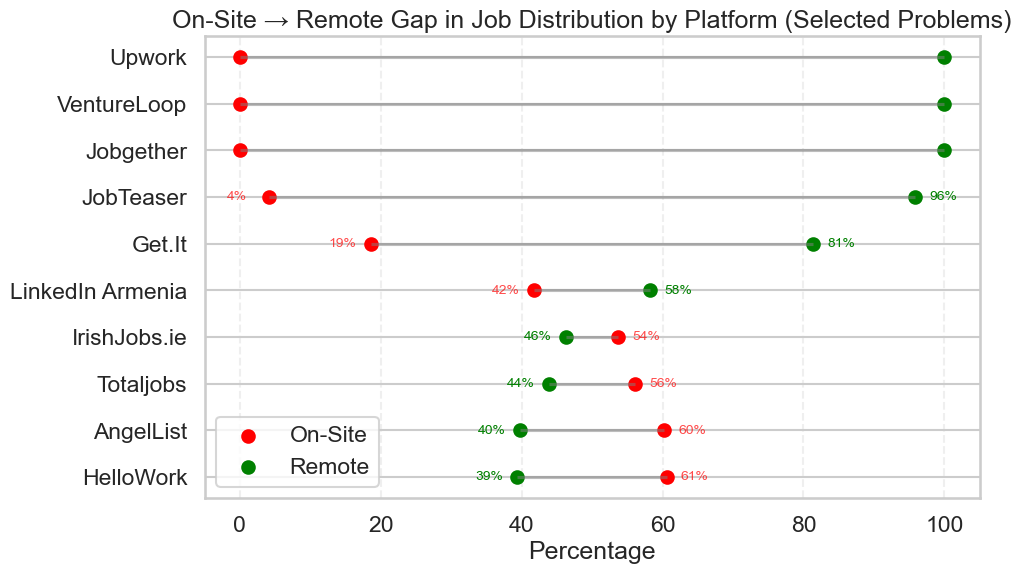

In [31]:
# Create figure
plt.figure(figsize=(10, 6))

# Draw horizontal lines connecting on-site and remote values (dumbbell chart)
plt.hlines(
    y=platform_df['Platform'],
    xmin=platform_df['Non_Remote'],         # Start (on-site %)
    xmax=platform_df['Remote_Percentage'],  # End (remote %)
    color='gray',
    alpha=0.5
)

# Plot points for on-site (red) and remote (green)
plt.scatter(
    platform_df['Non_Remote'],
    platform_df['Platform'],
    color='red',
    label='On-Site'
)

plt.scatter(
    platform_df['Remote_Percentage'],
    platform_df['Platform'],
    color='green',
    label='Remote'
)

# Add percentage labels dynamically based on relative values
for i, (remote, non_remote) in enumerate(
    zip(platform_df['Remote_Percentage'], platform_df['Non_Remote'])
):
    if non_remote > 0:

        if remote > non_remote:
            # Remote value is higher → place label on right
            plt.text(
                remote + 2,
                i,
                f"{remote:.0f}%",
                va='center',
                fontsize=10,
                color='green'
            )

            # On-site value → place label on left
            plt.text(
                non_remote - 6,
                i,
                f"{non_remote:.0f}%",
                va='center',
                fontsize=10,
                color='red',
                alpha=0.7
            )

        else:
            # Remote value is lower → place label on left
            plt.text(
                remote - 6,
                i,
                f"{remote:.0f}%",
                va='center',
                fontsize=10,
                color='green'
            )

            # On-site value → place label on right
            plt.text(
                non_remote + 2,
                i,
                f"{non_remote:.0f}%",
                va='center',
                fontsize=10,
                color='red',
                alpha=0.7
            )

# Add gridlines for better readability
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Set title and axis label
plt.title('On-Site → Remote Gap in Job Distribution by Platform (Selected Problems)')
plt.xlabel('Percentage')

# Add legend
plt.legend()

# Display the plot
plt.show()

## Role-Level Analysis: Salary vs Remote Opportunity vs Demand

This analysis explores the relationship between average salary, remote work availability, and job demand across different data roles.

- A scatter plot is used to compare roles based on:
  - X-axis: Average salary  
  - Y-axis: Proportion of remote jobs  
  - Bubble size: Job demand (number of postings)  
- Each point represents a role, with annotations for clear identification.
- The chart highlights how compensation and flexibility vary across roles.

In [32]:
# Aggregate data at role level to analyze salary, remote share, and demand
role_scatter = df.groupby('job_title_short').agg({
    'salary_year_avg': 'mean',       # Average salary per role
    'job_work_from_home': 'mean',    # Proportion of remote jobs (remote share)
    'job_title_short': 'count'       # Number of job postings (demand)
}).rename(columns={'job_title_short': 'job_count'}).reset_index()

role_scatter

,job_title_short,salary_year_avg,job_work_from_home,job_count
0,Business Analyst,91082.612833,0.056901,49015
1,Cloud Engineer,111268.453846,0.046340,12322
2,Data Analyst,93837.359753,0.067997,195862
3,Data Engineer,130125.604250,0.113931,185999
4,Data Scientist,135992.381984,0.084431,172116
5,Machine Learning Engineer,126774.315972,0.105757,14070
6,Senior Data Analyst,113911.363665,0.080256,29194
7,Senior Data Engineer,145840.611624,0.147122,44521
8,Senior Data Scientist,154206.292996,0.102770,36937
9,Software Engineer,113393.760054,0.065310,44832


### Plot Role Comparison Scatter chart

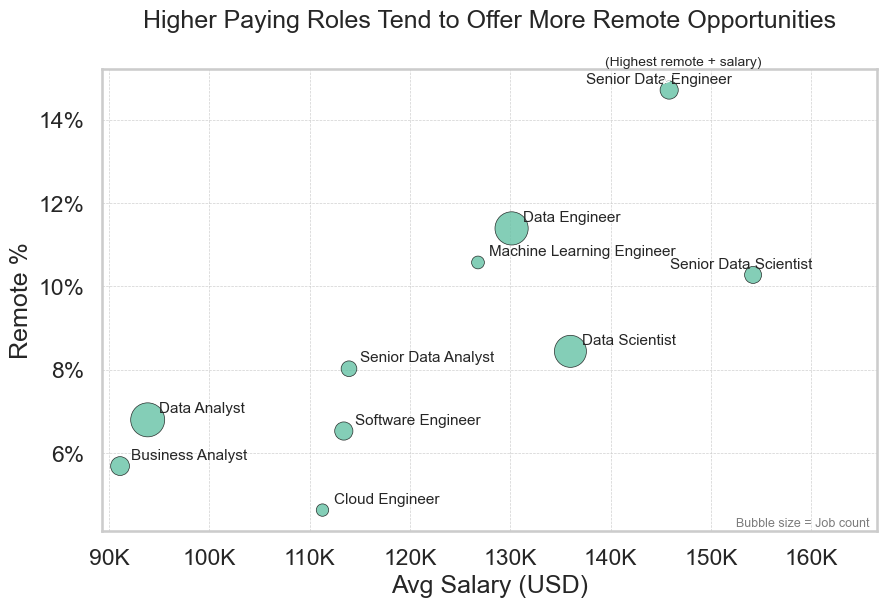

In [33]:
# Create figure
plt.figure(figsize=(10, 6))

# Scatter plot: salary vs remote share, with bubble size representing job demand
sns.scatterplot(
    data=role_scatter,
    x='salary_year_avg',        # Average salary
    y='job_work_from_home',     # Remote share (proportion)
    size='job_count',           # Bubble size represents demand
    sizes=(80, 600),            # Control range of bubble sizes
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5
)

# Remove default legend for cleaner appearance
plt.legend([], [], frameon=False)

# Add role labels near each point
for i in range(len(role_scatter)):
    x = role_scatter['salary_year_avg'][i]
    y = role_scatter['job_work_from_home'][i]
    label = role_scatter['job_title_short'][i]

    # Adjust label position for points near right edge
    if x > 140000:
        offset = (-60, 5)   # Shift label left
    else:
        offset = (8, 5)     # Default offset

    plt.annotate(
        label,
        (x, y),
        textcoords="offset points",
        xytext=offset,
        fontsize=11,
        fontweight='medium'
    )

# Highlight a key observation with annotation
plt.annotate(
    '(Highest remote + salary)',
    (145000, 0.148),
    textcoords="offset points",
    xytext=(-40, 15),
    fontsize=10,
    arrowprops=dict(arrowstyle='->', lw=1)
)

# Set title and axis labels
plt.title('Higher Paying Roles Tend to Offer More Remote Opportunities', pad=30)
plt.xlabel('Avg Salary (USD)')
plt.ylabel('Remote %')

# Add grid for readability
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

# Add note explaining bubble size
plt.text(
    0.99, 0.01,
    'Bubble size = Job count',
    transform=plt.gca().transAxes,
    ha='right',
    fontsize=9,
    alpha=0.6
)

# Format axes (salary in K, remote as %)
plt.gca().xaxis.set_major_formatter(lambda x, _: f'{int(x/1000)}K')
plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x*100:.0f}%')

# Adjust x-axis limits for better spacing
plt.xlim(
    role_scatter['salary_year_avg'].min() * 0.98,
    role_scatter['salary_year_avg'].max() * 1.08
)

# Display the plot
plt.show()

* Full-time roles dominate the market (~90%), with contract, internship, and part-time opportunities forming only a small fraction.
* Among non-full-time roles, Data Engineers have the highest contractor share, while Data Scientists show slightly higher internship presence.
* LinkedIn is the dominant hiring platform across all roles, followed by BeBee and Indeed, indicating where most opportunities are concentrated.
* Remote roles offer higher average salaries than on-site roles, suggesting a premium for flexible work arrangements.
* Job demand fluctuates over time, but remote work adoption shows a gradual upward trend, especially for Data Engineers.
* Higher-paying roles tend to offer more remote opportunities, with senior and specialized roles combining high salary, demand, and flexibility.
